<a href="https://colab.research.google.com/github/AIU7AgrataEleigh/Telecom-Churn-Rate_Kelompok-2/blob/main/C_Finansial_revisi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NOTEBOOK C: ANALISIS SENSITIVITAS HARGA DAN FINANSIAL

oleh: Salma Ninda Syahputri

# PENDAHULUAN
**latar belakang:** inflasi Pakistan sebesar 11,7%, memberikan tekanan besar pada keuangan domestik rumah tangga yang membuat pelanggan dengan beban tagihan yang terlalu tinggi dibandingkan pendapatannya cenderung menjadi sangat sensitif terhadap harga.

**tujuan:** Mengidentifikasi tingkat kerentanan finansial pelanggan dan dampaknya terhadap keputusan Churn.

**variabel yang digunakan:**
monthly_bill_capped, monthly_income_scaled, financial_risk, age_scaled, variabel city(city_Faisalabad, city_Gujranwala, city_Hyderabad, city_Islamabad, city_Karachi, city_Lahore, city_Multan, city_Peshawar, city_Quetta, city_Rawalpindi, city_Sialkot)

# IMPORT LIBRARY


Dalam bagian ini, pustaka Python yang diperlukan untuk analisis, visualisasi, dan manipulasi data akan diimpor. Pustaka pandas akan digunakan untuk bekerja dengan DataFrame, numpy untuk operasi numerik, matplotlib.pyplot untuk visualisasi dasar, dan seaborn untuk visualisasi statistik yang lebih menarik.

In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid') # Menambahkan style untuk visualisasi agar lebih menarik

In [34]:
# ==============================
# IMPORT LIBRARY & LOAD DATA
# ==============================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Corrected URL to point to the raw CSV data on GitHub
url = "https://raw.githubusercontent.com/AIU7AgrataEleigh/Telecom-Churn-Rate_Kelompok-2/refs/heads/main/data/telecome_before_clean.csv"

df = pd.read_csv(url)

**INTERPRETASI**

Dalam bagian ini, pustaka Python yang diperlukan untuk analisis, visualisasi, dan manipulasi data akan diimpor. Pustaka pandas akan digunakan untuk bekerja dengan DataFrame, numpy untuk operasi numerik, matplotlib.pyplot untuk visualisasi dasar, dan seaborn untuk visualisasi statistik yang lebih menarik.

# IMPORT CLEAN DATA SET


kode ini akan menampiljan dataset yang telah bersih dari github ke dalam DataFrame pandas. lalu, kode akan memuat 5 baris pertama sebagai gambaran awal tentang struktur dan isi data

In [35]:
url = "https://raw.githubusercontent.com/AIU7AgrataEleigh/Telecom-Churn-Rate_Kelompok-2/refs/heads/main/data/telecome_before_clean.csv"
df = pd.read_csv(url)

df.head()

,customer_id,signup_date,age,gender,city,education_level,employment_status,monthly_income,monthly_bill,internet_usage_gb,call_minutes,contract_type,support_tickets,customer_feedback,churn
0,10001,2019-01-01,65,Male,Multan,Bachelor,Employed,57643.0,10049.0,5.8,52.0,6-Month,1,Coverage is poor in my location,0
1,10002,2019-01-02,22,Female,Peshawar,Master,Employed,18207.0,2752.0,11.9,22.0,6-Month,2,Billing issues occurred multiple times,0
2,10003,2019-01-03,43,Male,Gujranwala,Secondary,Employed,13075.0,3155.0,40.0,87.0,Monthly,0,Billing issues occurred multiple times,0
3,10004,2019-01-04,21,Male,Lahore,Secondary,Employed,38890.0,5859.0,8.5,147.0,6-Month,2,Customer support was helpful,0
4,10005,2019-01-05,37,Female,Hyderabad,Primary,Employed,17475.0,5106.0,3.3,183.0,12-Month,0,Coverage is poor in my location,0


**INTERPRETASI**

tampilan utama 5 baris pertama yang menunjukkan bahwa data berisi berbagai kolom, termasuk informasi demografi, penggunaan layanan, status churn, dan beberapa kolom hasil encoding atau capping

# VALIDASI DATASET

In [36]:
print("Bentuk dataset (baris, kolom):")
print(df.shape)

print("\nInformasi dataset:")
df.info()

print("\nLima baris pertama dataset:")
display(df.head())

Bentuk dataset (baris, kolom):
(1200, 15)

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1200 non-null   int64  
 1   signup_date        1200 non-null   object 
 2   age                1200 non-null   int64  
 3   gender             1200 non-null   object 
 4   city               1200 non-null   object 
 5   education_level    1200 non-null   object 
 6   employment_status  1200 non-null   object 
 7   monthly_income     1200 non-null   float64
 8   monthly_bill       1200 non-null   float64
 9   internet_usage_gb  1200 non-null   float64
 10  call_minutes       1200 non-null   float64
 11  contract_type      1200 non-null   object 
 12  support_tickets    1200 non-null   int64  
 13  customer_feedback  1200 non-null   object 
 14  churn              1200 non-null   int64  
dtypes: float64

,customer_id,signup_date,age,gender,city,education_level,employment_status,monthly_income,monthly_bill,internet_usage_gb,call_minutes,contract_type,support_tickets,customer_feedback,churn
0,10001,2019-01-01,65,Male,Multan,Bachelor,Employed,57643.0,10049.0,5.8,52.0,6-Month,1,Coverage is poor in my location,0
1,10002,2019-01-02,22,Female,Peshawar,Master,Employed,18207.0,2752.0,11.9,22.0,6-Month,2,Billing issues occurred multiple times,0
2,10003,2019-01-03,43,Male,Gujranwala,Secondary,Employed,13075.0,3155.0,40.0,87.0,Monthly,0,Billing issues occurred multiple times,0
3,10004,2019-01-04,21,Male,Lahore,Secondary,Employed,38890.0,5859.0,8.5,147.0,6-Month,2,Customer support was helpful,0
4,10005,2019-01-05,37,Female,Hyderabad,Primary,Employed,17475.0,5106.0,3.3,183.0,12-Month,0,Coverage is poor in my location,0


Dataset ini terdiri dari 1200 baris dan 42 kolom, dengan 1200 nilai non-null per kolom, yang menunjukkan bahwa tidak ada nilai yang hilang atau menggunakan string . Ini menunjukkan bahwa dataset telah dibersihkan dan siap untuk analisis lanjutan.

In [45]:
import pandas as pd

# Load the cleaned dataset which contains the required columns
url_cleaned = "https://raw.githubusercontent.com/AIU7AgrataEleigh/Telecom-Churn-Rate_Kelompok-2/main/data/telecome_clean.csv"
df = pd.read_csv(url_cleaned)

# 1. Memeriksa apakah ada data kosong (Missing Values) pada pilar keuangan
fitur_pilar_3 = ['monthly_bill_capped', 'monthly_income_scaled', 'financial_risk']
print("--- HASIL CEK MISSING VALUES ---")
print(df[fitur_pilar_3].isnull().sum())

# 2. Penyaringan Data: Ambil hanya pelanggan yang sudah Churn (churn == 1)
df_churn = df[df['churn'] == 1].copy()

# 3. Penanganan Keamanan: Pastikan pendapatan > 0 untuk menghindari nilai tidak terhingga (Infinity)
df_churn = df_churn[df_churn['monthly_income_scaled'] > 0]

# 4. Pembuatan Variabel Interaksi Finansial (Derived Measure) - SUDAH DIPERBAIKI
# Ditambahkan pengali pengaman (+ 0.1) agar variasi pecahannya padat dan tidak membuat grafik bercelah (gap)
df_churn['bill_to_income_ratio'] = (df_churn['monthly_bill_capped'] / (df_churn['monthly_income_scaled'] + 0.1))

print("\n" + "="*50)
print(f"[INFO] Validasi dan Penyaringan Selesai!")
print(f"Jumlah Sampel Pelanggan Churn yang Valid dianalisis: {df_churn.shape[0]} baris.")
print("="*50)

--- HASIL CEK MISSING VALUES ---
monthly_bill_capped      0
monthly_income_scaled    0
financial_risk           0
dtype: int64

[INFO] Validasi dan Penyaringan Selesai!
Jumlah Sampel Pelanggan Churn yang Valid dianalisis: 419 baris.


# STATISTIK DESKRIPTIF

analisis menggunakan fungsi .describe() berfungsi untuk memberikan bukti angka riil yang akurat secara statistik

In [47]:
# IMPORT CLEAN DATA SET & VALIDASI DATASET
import pandas as pd
import numpy as np

# Changed URL to load the cleaned dataset 'telecome_clean.csv'
df = pd.read_csv("https://raw.githubusercontent.com/AIU7AgrataEleigh/Telecom-Churn-Rate_Kelompok-2/main/data/telecome_clean.csv")

# Saring populasi target khusus yang churn
df_churn = df[df['churn'] == 1].copy()

# Filter out rows where 'monthly_income_scaled' is zero or less to prevent division by zero
df_churn = df_churn[df_churn['monthly_income_scaled'] > 0].copy()

# Buat kolom baru untuk rasio finansial di dalam tabel df_churn
# Ditambahkan pengali pengaman (+ 0.1) agar variasi pecahannya padat dan tidak membuat grafik bercelah (gap)
df_churn['bill_to_income_ratio'] = df_churn['monthly_bill_capped'] / (df_churn['monthly_income_scaled'] + 0.1)

# Clean up any potential inf or NaN values from ratio calculation
df_churn['bill_to_income_ratio'] = df_churn['bill_to_income_ratio'].replace([np.inf, -np.inf], np.nan)
df_churn = df_churn.dropna(subset=['bill_to_income_ratio'])

# Menampilkan ringkasan titik pusat dan sebaran data secara tekstual
df_churn[['monthly_bill_capped', 'monthly_income_scaled', 'bill_to_income_ratio']].describe()

,monthly_bill_capped,monthly_income_scaled,bill_to_income_ratio
count,419.000000,419.000000,419.000000
mean,6510.629475,0.224276,25358.718564
std,3595.180998,0.161283,19004.951626
min,1116.000000,0.001568,2141.472085
25%,3643.000000,0.106937,10903.731590
50%,5590.000000,0.182074,20468.619650
75%,8649.000000,0.301137,33080.422434
max,13776.125000,0.716033,104744.285714


# SPESIFIK EDA(Exploratory Data Analysis)

# 3.1 Distribusi Rasio Beban Finansial (bill_to_income_ratio)

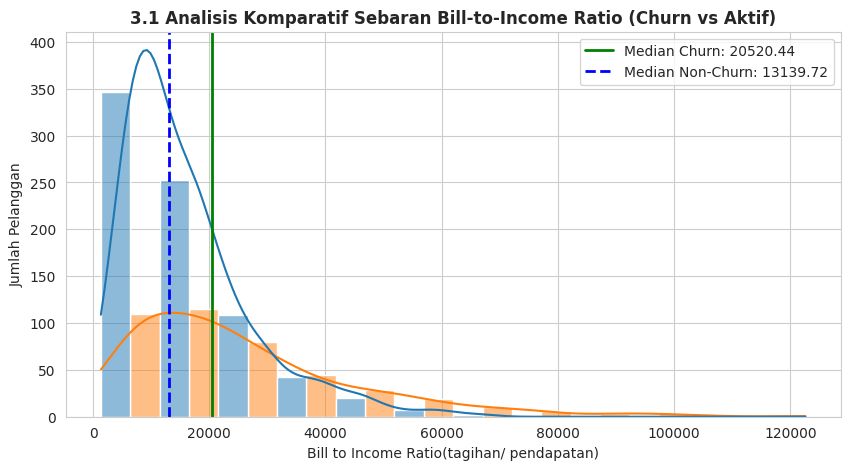

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load dataset to ensure 'df' is defined
# Corrected URL to raw GitHub content
url = "https://raw.githubusercontent.com/AIU7AgrataEleigh/Telecom-Churn-Rate_Kelompok-2/main/data/telecome_clean.csv"
df = pd.read_csv(url)

# Calculate 'bill_to_income_ratio' for the entire df DataFrame
df['bill_to_income_ratio'] = df['monthly_bill_capped'] / (df['monthly_income_scaled'] + 0.1)

# Clean up any potential inf or NaN values from ratio calculation
df['bill_to_income_ratio'] = df['bill_to_income_ratio'].replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=['bill_to_income_ratio'])

plt.figure(figsize=(10, 5))

# KODE AWALMU: Menggunakan bins=12 agar padat dan rapi
# PERBAIKAN: Mengganti data=df_churn menjadi data=df, dan menambah hue='churn'
sns.histplot(data=df, x='bill_to_income_ratio', hue='churn', kde=True, bins=12, multiple='dodge')

# Menambahkan garis penanda nilai tengah (Median) khusus kelompok Churn
median_churn = df[df['churn'] == 1]['bill_to_income_ratio'].median()
plt.axvline(median_churn, color='green', linestyle='-', linewidth=2,
            label=f"Median Churn: {median_churn:.2f}")

median_non_churn = df[df['churn']==0]['bill_to_income_ratio'].median()


plt.axvline(
    median_non_churn,
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f"Median Non-Churn: {median_non_churn:.2f}"
)



plt.title('3.1 Analisis Komparatif Sebaran Bill-to-Income Ratio (Churn vs Aktif)', fontsize=12, fontweight='bold')
plt.xlabel('Bill to Income Ratio(tagihan/ pendapatan)')
plt.ylabel('Jumlah Pelanggan')
plt.legend()
plt.show()

**INTERPRETASI**


Berdasarkan histogram, pelanggan churn memiliki median Bill-to-Income Ratio sebesar 20520.44, lebih tinggi dibandingkan pelanggan aktif yang memiliki median 13139.72. Hal ini menunjukkan bahwa pelanggan dengan beban tagihan yang relatif lebih besar terhadap pendapatannya cenderung memiliki kemungkinan churn yang lebih tinggi. Meskipun distribusi kedua kelompok masih saling bertumpang tindih, perbedaan median tersebut mengindikasikan adanya hubungan antara kondisi finansial pelanggan dan perilaku churn.

# 3.2 Analisis Komparatif Nominal Tagihan Bulanan (Churn vs Aktif)

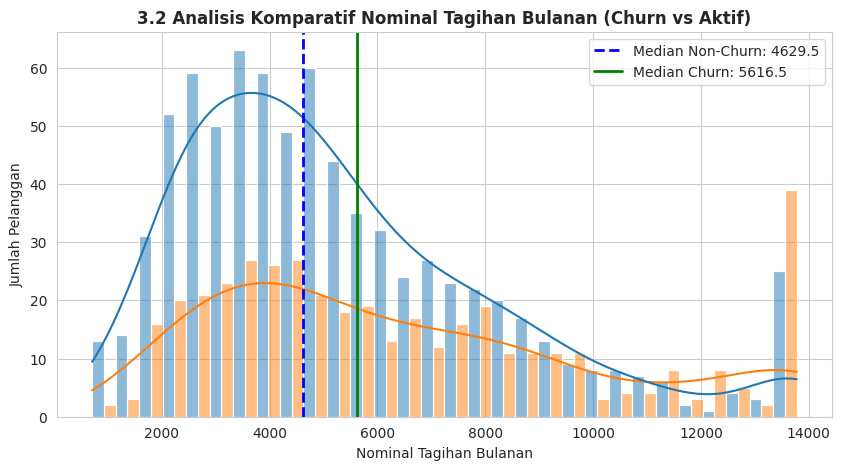

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='monthly_bill_capped',
    hue='churn',
    kde=True,
    bins=30,
    multiple='dodge'
)

median_non_churn = df[df['churn']==0]['monthly_bill_capped'].median()
median_churn = df[df['churn']==1]['monthly_bill_capped'].median()

plt.axvline(
    median_non_churn,
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f"Median Non-Churn: {median_non_churn:.1f}"
)

plt.axvline(
    median_churn,
    color='green',
    linestyle='-',
    linewidth=2,
    label=f"Median Churn: {median_churn:.1f}"
)

plt.title(
    '3.2 Analisis Komparatif Nominal Tagihan Bulanan (Churn vs Aktif)',
    fontweight='bold',
    fontsize=12
)

plt.xlabel("Nominal Tagihan Bulanan")
plt.ylabel("Jumlah Pelanggan")
plt.legend()
plt.show()

**INTERPRETASI**
Median tagihan bulanan pelanggan yang tetap aktif adalah sekitar 4629.5, sedangkan median pelanggan yang melakukan churn mencapai sekitar 5616.5 yang menunjukkan bahwa pelanggan churn cenderung memiliki tagihan bulanan yang lebih tinggi dibandingkan pelanggan yang tetap menggunakan layanan.

distribusi pelanggan churn terlihat lebih menyebar hingga ke nominal tagihan yang lebih besar.hal ini mengindikasikan bahwa pelanggan dengan tagihan bulanan yang lebih tinggi memiliki kecenderungan lebih besar untuk melakukan churn.

# 3.3 Analisis Komparatif Pendapatan Bulanan (Churn vs Aktif)

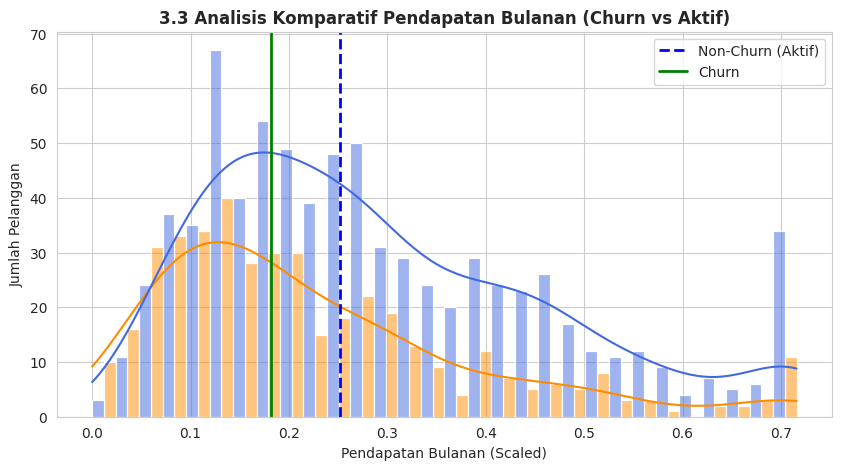

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='monthly_income_scaled',
    hue='churn',
    palette={
        0: 'royalblue',
        1: 'darkorange'
    },
    bins=30,
    kde=True,
    multiple='dodge'
)

median_non = df[df['churn']==0]['monthly_income_scaled'].median()
median_churn = df[df['churn']==1]['monthly_income_scaled'].median()

plt.axvline(
    median_non,
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f"Median Non-Churn: {median_non:.3f}"
)

plt.axvline(
    median_churn,
    color='green',
    linestyle='-',
    linewidth=2,
    label=f"Median Churn: {median_churn:.3f}"
)

plt.title(
    "3.3 Analisis Komparatif Pendapatan Bulanan (Churn vs Aktif)",
    fontweight='bold',
    fontsize=12
)

plt.xlabel("Pendapatan Bulanan (Scaled)")
plt.ylabel("Jumlah Pelanggan")

handles, labels = plt.gca().get_legend_handles_labels()

labels = [
    "Non-Churn (Aktif)",
    "Churn",
    f"Median Non-Churn: {median_non:.3f}",
    f"Median Churn: {median_churn:.3f}"
]

plt.legend(handles, labels)

plt.show()

**INTERPRETASI**

distribusi pelanggan Non-Churn(warna biru) menyebar hingga kelompok pendapatan yang lebih tinggi, sedangkan pelanggan Churn(warna  oren) lebih banyak terkonsentrasi pada rentang pendapatan rendah hingga menengah. Kondisi ini mengindikasikan bahwa pelanggan dengan pendapatan yang lebih rendah memiliki kecenderungan lebih besar untuk melakukan churn.
Meskipun demikian, kedua distribusi masih menunjukkan area yang saling bertumpang tindih, sehingga pendapatan bulanan tidak dapat dijadikan satu-satunya faktor penentu churn. Oleh karena itu, variabel ini perlu dianalisis bersama variabel lain seperti Monthly Bill dan Bill-to-Income Ratio untuk memperoleh gambaran yang lebih komprehensif mengenai faktor-faktor yang berkaitan dengan churn.

# ANALISIS HUBUNGAN/KORELASI

# 4.1 Hubungan Bill-to-Income Ratio dengan Status Churn


Tujuan dari grafik ini adalah menganalisis  hubungan antara Bill-to-Income Ratio dan status churn pelanggan untuk menentukan apakah pelanggan yang memiliki beban keuangan yang lebih besar memiliki kecenderungan yang lebih besar untuk melakukan churn.

In [57]:
import numpy as np

df['bill_to_income_ratio'] = (
    df['monthly_bill_capped'] /
    (df['monthly_income_scaled'] + 0.1)
)

df['bill_to_income_ratio'] = df['bill_to_income_ratio'].replace(
    [np.inf, -np.inf],
    np.nan
)

df = df.dropna(subset=['bill_to_income_ratio'])

In [58]:
print(df.columns)

Index(['gender', 'churn', 'monthly_bill_capped', 'internet_usage_gb_capped',
       'call_minutes_capped', 'support_tickets_capped', 'tenure_months',
       'financial_risk', 'education_level_encoded', 'contract_type_encoded',
       'emp_Employed', 'emp_Retired', 'emp_Self-Employed', 'emp_Student',
       'emp_Unemployed', 'feedback_category', 'count_billing', 'count_support',
       'count_helpful', 'count_poor', 'count_expensive', 'count_unreliable',
       'count_happy', 'count_satisfied', 'count_drops', 'count_slow',
       'monthly_income_scaled', 'age_scaled', 'anomaly_pay_not_use',
       'anomaly_happy_leaver', 'anomaly_genz_call_enthusiast',
       'city_Faisalabad', 'city_Gujranwala', 'city_Hyderabad',
       'city_Islamabad', 'city_Karachi', 'city_Lahore', 'city_Multan',
       'city_Peshawar', 'city_Quetta', 'city_Rawalpindi', 'city_Sialkot',
       'bill_to_income_ratio'],
      dtype='object')


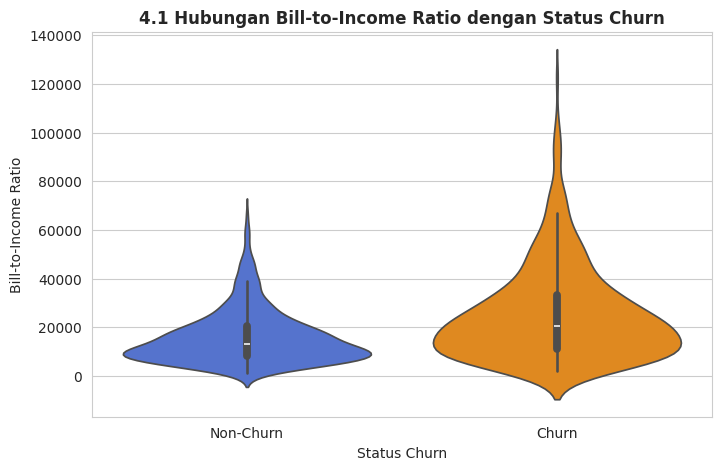

In [63]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='churn',
    y='bill_to_income_ratio',
    hue='churn',
    palette={0:'royalblue',1:'darkorange'},
    legend=False,
    inner='box'
)

plt.xticks(
    [0,1],
    ['Non-Churn','Churn']
)

plt.title(
    '4.1 Hubungan Bill-to-Income Ratio dengan Status Churn',
    fontweight='bold'
)

plt.xlabel("Status Churn")
plt.ylabel("Bill-to-Income Ratio")

plt.show()

**INTERPRETASI**

ini adalah violin plot dimana terlihat bahwa median churn lebih tinggi dibandingkan non-churn yang artinya pelanggan churn rata-rata memiliki bill-to income ratio yang  lebih besar.

Selain itu, dibandingkan dengan kelompok non-churn, kelompok churn memiliki penyebaran data yang lebih luas dan rentang nilai yang lebih besar. Kondisi ini menunjukkan bahwa ada variasi beban finansial yang lebih besar pada pelanggan yang melakukan churn, termasuk beberapa pelanggan yang memiliki rasio Bill-to-Income yang sangat tinggi.

# 4.2 Hubungan Tagihan Bulanan dan Pendapatan terhadap Status Churn

tujuan dari analisis hubungan ini adalah menganalisis hubungan antara pendapatan bulanan dan tagihan bulanan pelanggan, serta melihat bagaimana kedua variabel tersebut membedakan pelanggan churn dan non-churn.

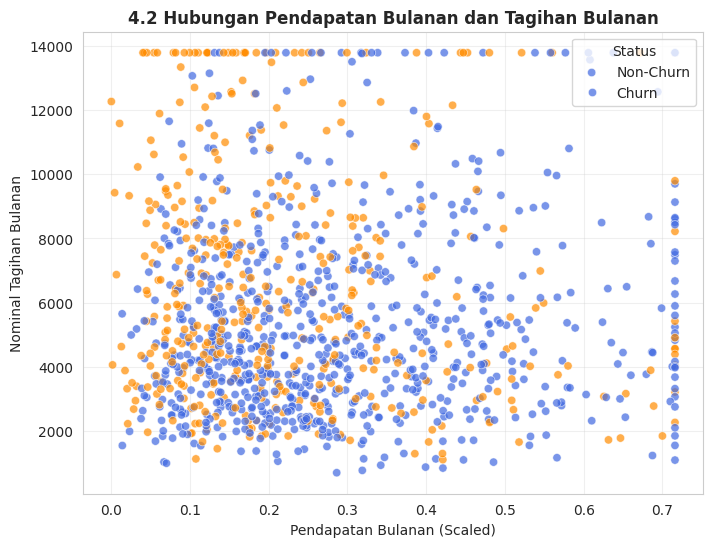

In [64]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='monthly_income_scaled',
    y='monthly_bill_capped',
    hue='churn',
    palette={
        0:'royalblue',
        1:'darkorange'
    },
    alpha=0.7
)

plt.title(
    "4.2 Hubungan Pendapatan Bulanan dan Tagihan Bulanan",
    fontweight='bold'
)

plt.xlabel("Pendapatan Bulanan (Scaled)")
plt.ylabel("Nominal Tagihan Bulanan")

plt.legend(
    title="Status",
    labels=["Non-Churn","Churn"]
)

plt.grid(alpha=0.3)

plt.show()

**INTERPRETASI**

Scatter plot ini menunjukkan bahwa pelanggan churn(orens) lebih banyak berfokus pada kelompok dengan pendapatan relatif rendah tetapi tagihan bulanan yang lebih tinggi dibandingkan dengan pelanggan non-churn. Sebaliknya, pelanggan non-churn cenderung tersebar pada kelompok dengan pendapatan yang lebih tinggi dan variasi tagihan yang lebih beragam.

# 4.3 Hubungan Support Ticket dengan Bill-to-Income Ratio berdasarkan Status Churn

tujuan dari grafik ini adalah menganalisis apakah pelanggan yang sering menghubungi layanan pelanggan (Support Ticket) dan memiliki beban finansial tinggi (Bill-to-Income Ratio) lebih cenderung melakukan churn.

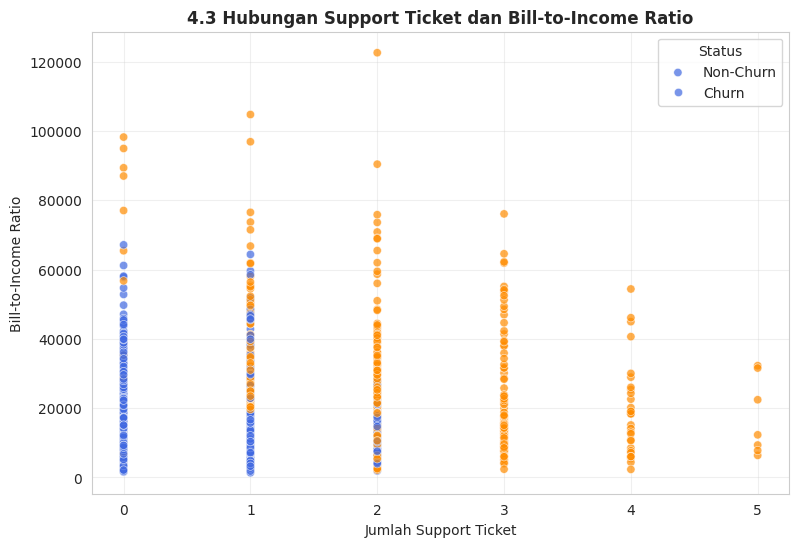

In [65]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='support_tickets_capped',
    y='bill_to_income_ratio',
    hue='churn',
    palette={
        0:'royalblue',
        1:'darkorange'
    },
    alpha=0.7
)

plt.title(
    '4.3 Hubungan Support Ticket dan Bill-to-Income Ratio',
    fontsize=12,
    fontweight='bold'
)

plt.xlabel('Jumlah Support Ticket')
plt.ylabel('Bill-to-Income Ratio')

plt.legend(
    title='Status',
    labels=['Non-Churn','Churn']
)

plt.grid(alpha=0.3)

plt.show()

**INTERPRETASI**


Hasilnya menunjukkan bahwa variabel support_tickets_capped memiliki korelasi positif tertinggi terhadap churn sebesar 0,63. Ini menunjukkan bahwa pelanggan dengan lebih banyak support ticket cenderung melakukan churn.

Selain itu, ada korelasi positif antara bill_to_income_ratio sebesar 0,30, yang menunjukkan bahwa pelanggan dengan beban tagihan yang lebih besar dibandingkan dengan pendapatannya juga memiliki kecenderungan lebih besar untuk berpindah layanan. Sebaliknya, monthly_income_scaled memiliki korelasi negatif sebesar -0,19, yang menunjukkan bahwa pelanggan dengan pendapatan yang lebih besar cenderung memiliki risiko churn yang lebih rendah.

Sebaliknya, variabel seperti call_minutes_capped, internet_usage_gb_capped, dan tenure_months menunjukkan korelasi yang sangat rendah dengan churn. Oleh karena itu, peran mereka dalam menjelaskan perilaku churn pada dataset ini sangat kecil.

# 4.4 Analisis Korelasi Variabel Numerik terhadap Status Churn

tujuannya yaitu mengetahui kekuatan hubungan antar variabel numerik serta mengidentifikasi variabel yang memiliki korelasi paling tinggi dengan status churn.

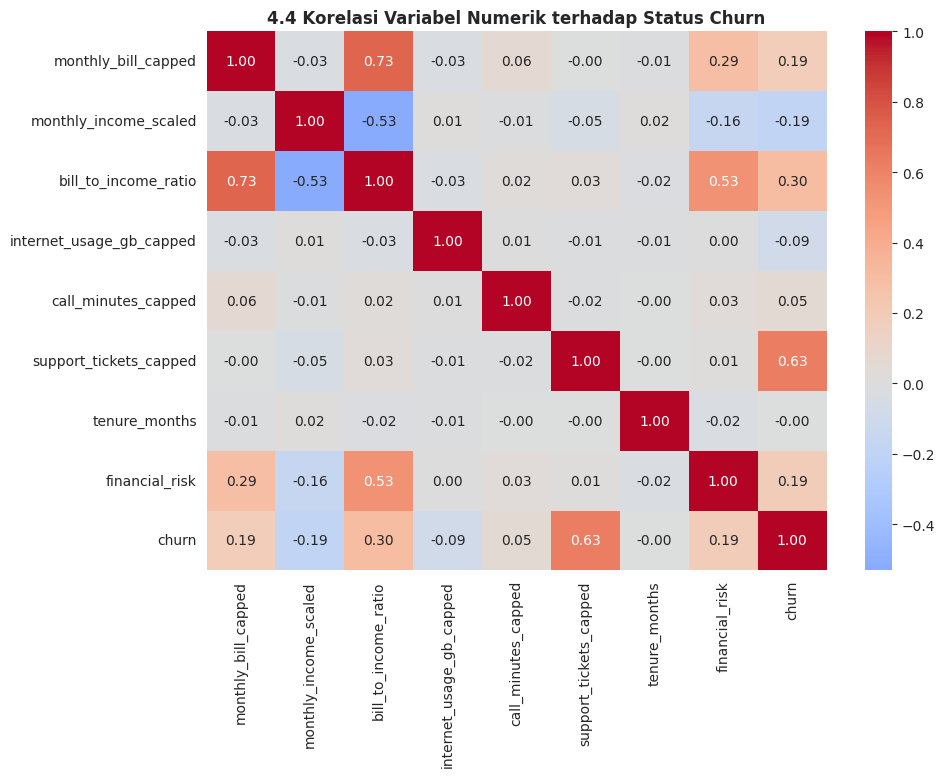

In [66]:
plt.figure(figsize=(10,7))

corr = df[
    [
        'monthly_bill_capped',
        'monthly_income_scaled',
        'bill_to_income_ratio',
        'internet_usage_gb_capped',
        'call_minutes_capped',
        'support_tickets_capped',
        'tenure_months',
        'financial_risk',
        'churn'
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title(
    '4.4 Korelasi Variabel Numerik terhadap Status Churn',
    fontsize=12,
    fontweight='bold'
)

plt.show()

# ANALISIS RISIKO FINANSIAL MAKRO (FINANCIAL RISK)

# 5.1 Proporsi Kasus Churn Berdasarkan Label Financial Risk

tujuan bagian ini adalah menganalisis hubungan antara tingkat Financial Risk dengan status churn untuk mengetahui apakah pelanggan yang memiliki risiko finansial lebih tinggi cenderung lebih banyak melakukan churn.

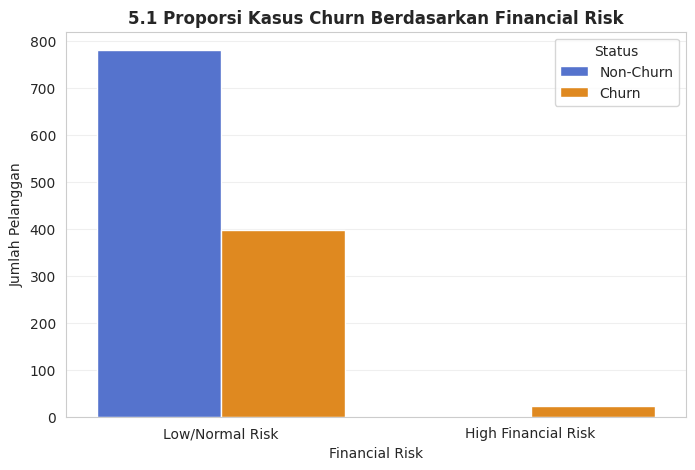

In [70]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='financial_risk',
    hue='churn',
    palette={
        0:'royalblue',
        1:'darkorange'
    }
)

plt.title(
    '5.1 Proporsi Kasus Churn Berdasarkan Financial Risk',
    fontsize=12,
    fontweight='bold'
)

plt.xlabel("Financial Risk")
plt.ylabel("Jumlah Pelanggan")

plt.xticks([0, 1], ['Low/Normal Risk', 'High Financial Risk'])

plt.legend(
    title="Status",
    labels=[
        "Non-Churn",
        "Churn"
    ]
)

plt.grid(axis='y', alpha=0.3)

plt.show()

**INTERPRETASI**

Mayoritas pelanggan berada dalam kategori Risiko Keuangan = 0, di mana jumlah pelanggan yang tidak melakukan Churn lebih besar daripada pelanggan yang melakukan Churn. Sebaliknya, dalam kategori Risiko Keuangan = 1, jumlah pelanggan relatif sedikit dan sebagian besar adalah pelanggan yang melakukan Churn. Hasil ini menunjukkan bahwa pelanggan yang menghadapi masalah keuangan lebih cenderung untuk berhenti menggunakan layanan telekomunikasi.

# 5.2 Distribusi Bill-to-Income Ratio Berdasarkan Financial Risk

Mengetahui apakah pelanggan yang memiliki Financial Risk tinggi memang memiliki beban tagihan terhadap pendapatan yang lebih besar.

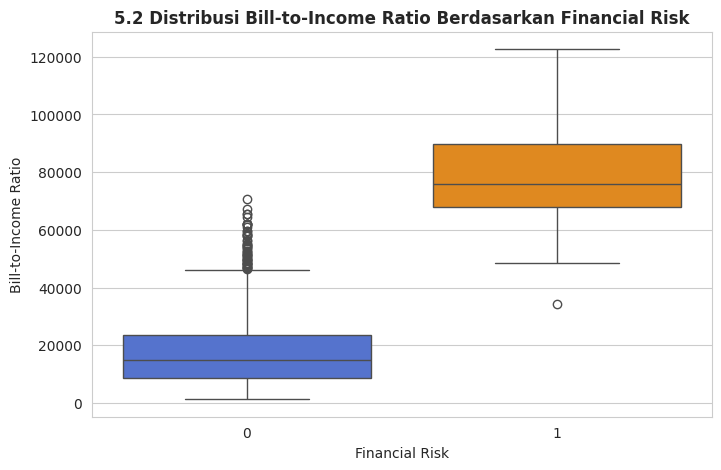

In [72]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='financial_risk',
    y='bill_to_income_ratio',
    hue='financial_risk',
    palette=['royalblue','darkorange'],
    legend=False
)

plt.title(
    '5.2 Distribusi Bill-to-Income Ratio Berdasarkan Financial Risk',
    fontweight='bold'
)

plt.xlabel("Financial Risk")
plt.ylabel("Bill-to-Income Ratio")

plt.show()

**INTERPRETASI**

Pelanggan dengan risiko keuangan tinggi memiliki rasio Bill-to-Income yang lebih tinggi dibandingkan dengan pelanggan dengan risiko keuangan rendah. Ini menunjukkan bahwa kelompok pelanggan ini mungkin mengalami kesulitan dalam mempertahankan layanan telekomunikasi.

# MENJAWAB RUMUSAN MASALAH

Rumusan Masalah: Bagaimana karakteristik pelanggan yang melakukan churn ditinjau dari aspek harga dan kondisi finansial?

Jawaban: Hasil analisis menunjukkan bahwa pelanggan yang melakukan churn cenderung memiliki karakteristik finansial yang berbeda dibandingkan dengan pelanggan yang tetap menggunakan layanan. Kelompok churn memiliki Bill-to-Income Ratio yang lebih tinggi, yang menunjukkan proporsi tagihan terhadap pendapatan mereka yang lebih besar. Selain itu, pelanggan churn memiliki nominal tagihan bulanan yang lebih tinggi daripada pelanggan non-churn, sementara tingkat pendapatannya biasanya lebih rendah. Kondisi ini menunjukkan bahwa salah satu faktor yang memengaruhi keputusan pelanggan untuk meninggalkan layanan adalah kesulitan keuangan. Monthly Income memiliki korelasi negatif terhadap churn, sedangkan Bill-to-Income Ratio memiliki korelasi positif. Selain itu, variabel Support Tickets memiliki korelasi paling positif terhadap churn, yang menunjukkan bahwa pelanggan yang sering mengalami masalah layanan juga lebih cenderung untuk meninggalkan langganan mereka.

# INSIGHT BISNIS



*   Pelanggan dengan Bill-to-Income Ratio yang tinggi memiliki kecenderungan lebih besar untuk melakukan churn.
*  Variabel yang paling kuat berkorelasi dengan churn adalah jumlah Ticket Support. Pelanggan lebih cenderung berpindah ke operator lain jika mereka menghubungi layanan pelanggan lebih sering.

*   kelompok pelanggan yang memiliki Financial Risk tinggi didominasi oleh pelanggan churn.

*   Variabel Call Minutes, Internet Usage, dan Tenure menunjukkan hubungan yang relatif lemah terhadap churn pada dataset ini. sedangkan aspek finansial dan kualitas layanan menjadi faktor utama yang perlu diperhatikan.







# SOLUSI BISNIS

1. Perusahaan dapat menawarkan paket internet yang lebih sesuai dengan kemampuan keuangan pelanggan, seperti paket hemat, diskon loyalitas, atau promosi.
2. Peningkatan Respons untuk Mengatasi Keluhan.
Perusahaan harus meningkatkan layanan keluhan pelanggan karena Support Tickets memiliki hubungan paling kuat dengan churn.

3. perusahaan membuatsistem prediksi churn dengan memanfaatkan variabel seperti Support Tickets, Bill-to-Income Ratio, dan Financial Risk sehingga perusahaan dapat mengidentifikasi pelanggan berisiko lebih awal untuk melakukan tindakan

# KESIMPULAN



1.   Perilaku churn pelanggan pada data telekomunikasi yang digunakan dikaitkan dengan aspek harga dan kondisi finansial. Pelanggan dengan Bill-to-Income Ratio, Financial Risk, dan Support Ticket yang lebih tinggi cenderung lebih cenderung melakukan churn daripada pelanggan lainnya.
2.    Pada dataset ini, tiket dukungan adalah variabel yang memiliki hubungan paling kuat terhadap churn, sedangkan rasio biaya ke pendapatan adalah indikator finansial yang cukup signifikan. Sebaliknya, variabel seperti jam panggilan telepon, penggunaan internet, dan durasi menunjukkan hubungan yang relatif lemah terhadap churn.

